# Data Classification (KNN)
Para aplicar un modelo de clasificación con el algoritmo **K-Nearest Neighbors (KNN)**, necesitamos un problema donde el objetivo sea predecir una "clase" o "categoría".
Dado que nuestro dataset contiene valores porcentuales continuos, convertiremos esto en un problema de **Clasificación Binaria**
Filtraremos el dataset para enfrentar dos indicadores que comparten contextos demográficos pero representan realidades distintas:

DE
KNN es un algoritmo basado en la similitud (distancia espacial). Nuestro modelo analizará las variables numéricas (`Value`, `LowCI`, `HighCI`) de un registro anónimo y, al observar a sus "vecinos más cercanos", decidirá si los números corresponden a una población que logró acceder a terapia o a una que no pudo.



In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/Mental_Health_Clean_Final.csv")

# Clases
ind_0 = "Received Counseling or Therapy, Last 4 Weeks"
ind_1 = "Needed Counseling or Therapy But Did Not Get It, Last 4 Weeks"
df_clf = df[df['Indicator'].isin([ind_0, ind_1])].copy()

# FEATURE ENGINEERING
# Creamos una nueva métrica: 'CI_Spread'. La amplitud del intervalo nos dice qué tan variable/incierta es la muestra.
df_clf['CI_Spread'] = df_clf['HighCI'] - df_clf['LowCI']
df_clf['Time Period'] = df_clf['Time Period'].astype(str)

# 4. separacion de atributos relevantes
num_features = ['Value', 'LowCI', 'HighCI', 'CI_Spread']
cat_features = ['Group', 'Subgroup', 'State', 'Time Period'] # Damos contexto espacial y temporal completo

df_clf = df_clf.dropna(subset=num_features + cat_features)

y = np.where(df_clf['Indicator'] == ind_0, 1, 0)
X = df_clf[num_features + cat_features]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


# solo aplicamos StandardScaler a los números y OneHotEncoder a las categorías para no romper la distancia del KNN
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features)
    ])

In [9]:
# pipeline y búsqueda de hiperparámetros
knn_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier())
])

param_grid = {'classifier__n_neighbors': np.arange(1, 31, 2)}
knn_cv = GridSearchCV(knn_pipe, param_grid, cv=5, scoring='f1')
knn_cv.fit(X_train, y_train)

k_optimo = knn_cv.best_params_['classifier__n_neighbors']
print(f"Mejor hiperparámetro k encontrado: {k_optimo}")
print(f"F1-Score en Validación Cruzada: {knn_cv.best_score_:.4f}")

Mejor hiperparámetro k encontrado: 19
F1-Score en Validación Cruzada: 0.6813


Resultados del Modelo Óptimo (KNN):
Exactitud (Accuracy):  0.6707
Precisión (Precision): 0.6742
Sensibilidad (Recall): 0.6633
Especificidad:         0.6781
Valor F1 (F1-Score):   0.6687



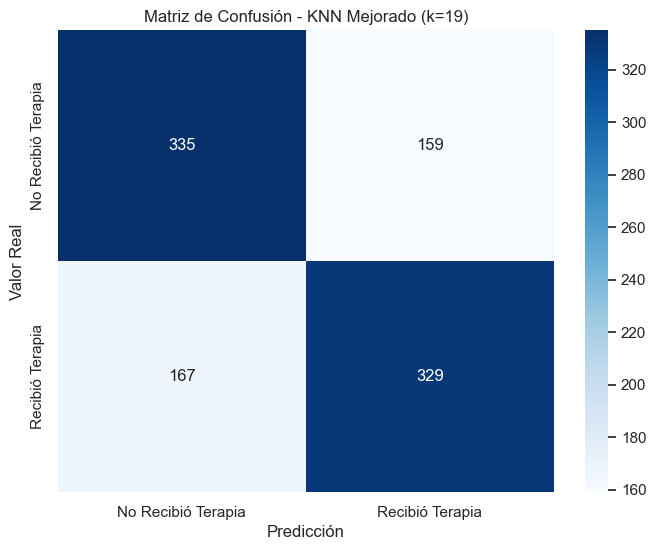

In [10]:
# predicción y métricas
knn_final = knn_cv.best_estimator_
y_pred_knn = knn_final.predict(X_test)

cm = confusion_matrix(y_test, y_pred_knn)
TN, FP, FN, TP = cm.ravel()

accuracy = accuracy_score(y_test, y_pred_knn)
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0 # Sensibilidad
especificidad = TN / (TN + FP) if (TN + FP) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print("Resultados del Modelo Óptimo (KNN):")
print(f"Exactitud (Accuracy):  {accuracy:.4f}")
print(f"Precisión (Precision): {precision:.4f}")
print(f"Sensibilidad (Recall): {recall:.4f}")
print(f"Especificidad:         {especificidad:.4f}")
print(f"Valor F1 (F1-Score):   {f1:.4f}\n")

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Recibió Terapia', 'Recibió Terapia'],
            yticklabels=['No Recibió Terapia', 'Recibió Terapia'])
plt.title(f'Matriz de Confusión - KNN Mejorado (k={k_optimo})')
plt.ylabel('Valor Real')
plt.xlabel('Predicción')
plt.show()

In [11]:
# entrenamos un Random Forest usando exactamente el mismo pipeline para comparacion
rf_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, class_weight='balanced'))
])
rf_pipe.fit(X_train, y_train)
y_pred_rf = rf_pipe.predict(X_test)

f1_rf = classification_report(y_test, y_pred_rf, output_dict=True)['1']['f1-score']
acc_rf = accuracy_score(y_test, y_pred_rf)

print("Comparativa Final (Conjunto de Prueba):")
print(f"KNN           -> Accuracy: {accuracy:.4f} | F1-Score: {f1:.4f}")
print(f"Random Forest -> Accuracy: {acc_rf:.4f} | F1-Score: {f1_rf:.4f}")

Comparativa Final (Conjunto de Prueba):
KNN           -> Accuracy: 0.6707 | F1-Score: 0.6687
Random Forest -> Accuracy: 0.6293 | F1-Score: 0.6398
